In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_squared_error
df = pd.read_csv(r"C:\Users\Pratyasha\Downloads\Section C\set4_stock.csv")
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
df.info

<bound method DataFrame.info of             Open        High         Low   Volume  Previous_Close       Close
0     130.850591  109.469182   82.061195  80632.0      102.552572  112.654155
1     138.482716  151.432974   85.198435  55347.0       77.659546  114.028195
2      80.389045  107.996553   62.902595  80809.0       84.681006   84.387189
3      95.989097   72.647132   47.251787  30458.0       87.019995   76.230986
4     102.336459         NaN   85.786564  20937.0      102.926927  104.227860
...          ...         ...         ...      ...             ...         ...
5095  109.883083  145.178754   40.481263  98274.0       82.888960  100.890614
5096   93.880124  138.071233   73.216388  81917.0      130.484245  106.102740
5097  114.288995   94.528153  108.636530      NaN       74.208073         NaN
5098  110.564838  107.639449   93.669502  82902.0             NaN  106.128488
5099   86.978334   78.024197   84.234330  90225.0      102.791190   86.359416

[5100 rows x 6 columns]>

In [55]:
df.isnull().sum()

Open              181
High              209
Low               198
Volume            206
Previous_Close    206
Close             202
dtype: int64

In [56]:
df = df.drop_duplicates()

In [57]:
df['Open'] = df['Open'].fillna(df['Open'].median())
df['High'] = df['High'].fillna(df['High'].median())
df['Low'] = df['Low'].fillna(df['Low'].median())
df['Volume'] = df['Volume'].fillna(df['Volume'].median())
df['Previous_Close'] = df['Previous_Close'].fillna(df['Previous_Close'].median())
df['Close'] = df['Close'].fillna(df['Close'].median())

C:\Users\Pratyasha\AppData\Local\Temp\ipykernel_22188\3369500577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Open'] = df['Open'].fillna(df['Open'].median())
C:\Users\Pratyasha\AppData\Local\Temp\ipykernel_22188\3369500577.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['High'] = df['High'].fillna(df['High'].median())
C:\Users\Pratyasha\AppData\Local\Temp\ipykernel_22188\3369500577.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

In [58]:
df.info

<bound method DataFrame.info of             Open        High         Low   Volume  Previous_Close       Close
0     130.850591  109.469182   82.061195  80632.0      102.552572  112.654155
1     138.482716  151.432974   85.198435  55347.0       77.659546  114.028195
2      80.389045  107.996553   62.902595  80809.0       84.681006   84.387189
3      95.989097   72.647132   47.251787  30458.0       87.019995   76.230986
4     102.336459  110.077264   85.786564  20937.0      102.926927  104.227860
...          ...         ...         ...      ...             ...         ...
4995   98.963420  115.968753   74.752916  78466.0      108.638449  105.376275
4996  107.258327  120.770621   90.112569  85098.0       84.657083   93.827951
4997  113.663243   76.537205  109.074323  85477.0       72.353747   94.012873
4998   93.636395   89.209848   88.845345   2543.0      111.543189   95.801993
4999   92.823365  107.272266   88.762109  61298.0      118.394746  112.031314

[5000 rows x 6 columns]>

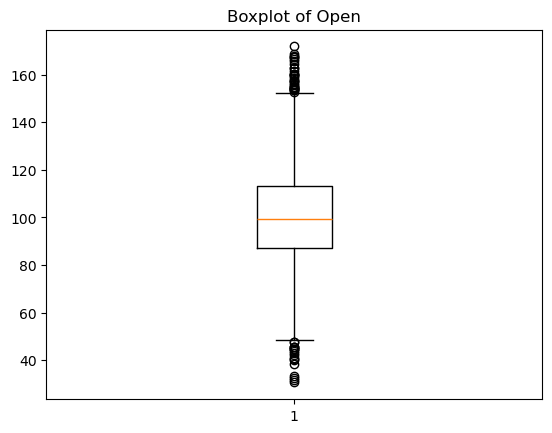

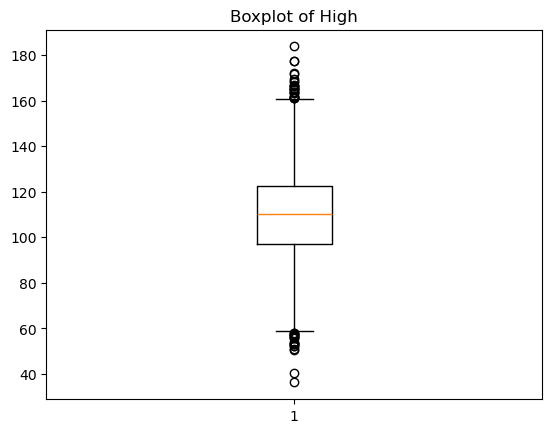

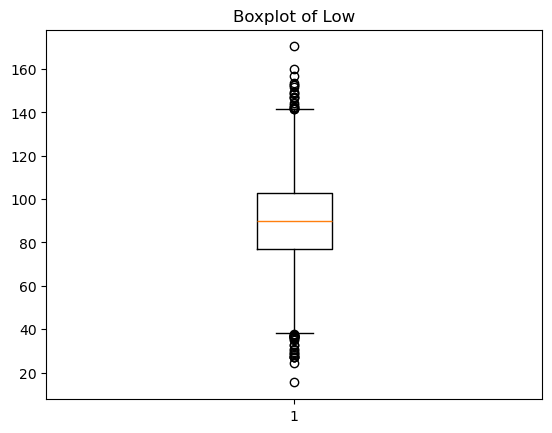

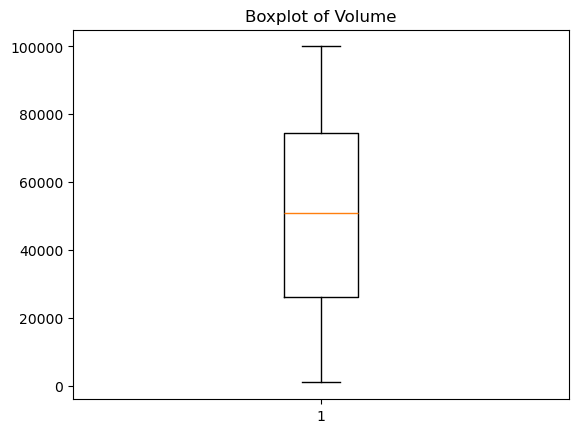

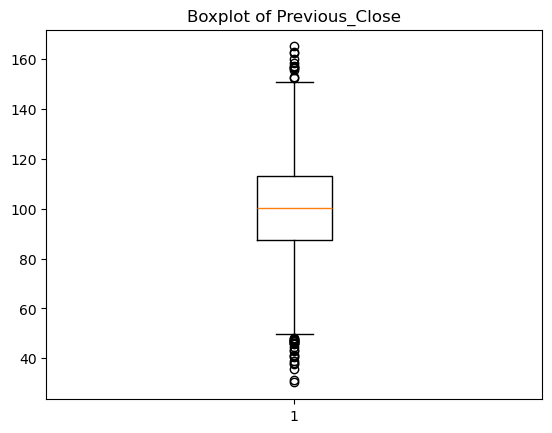

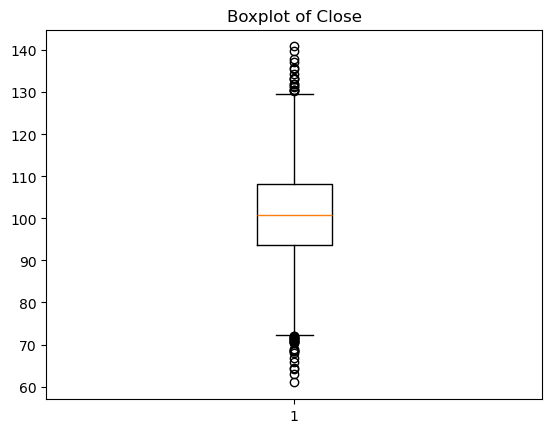

In [59]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

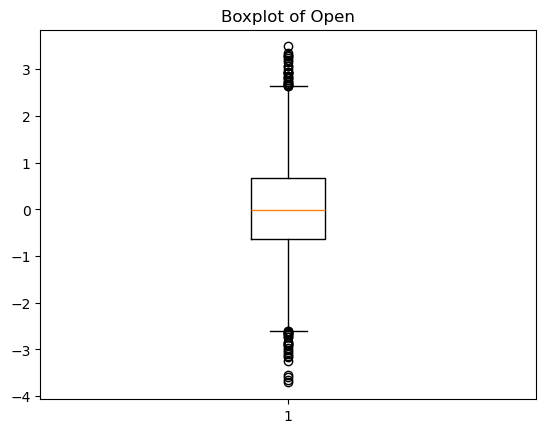

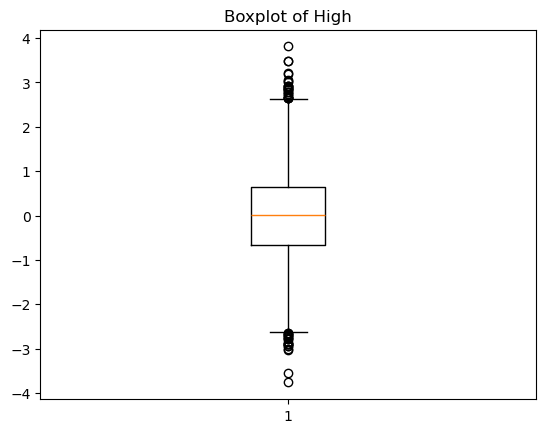

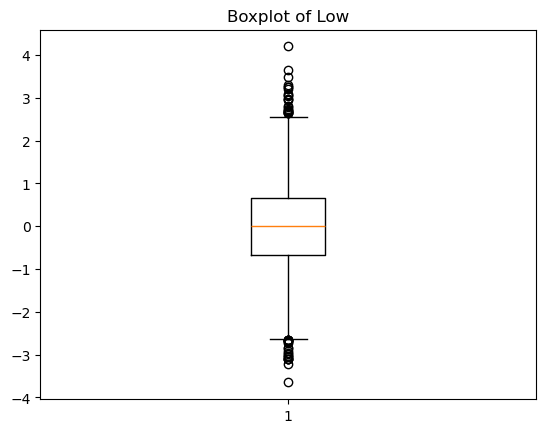

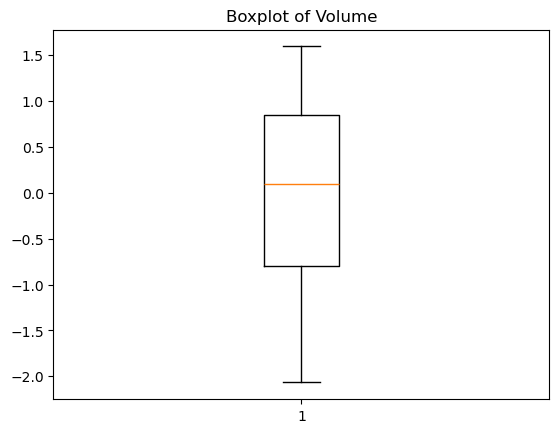

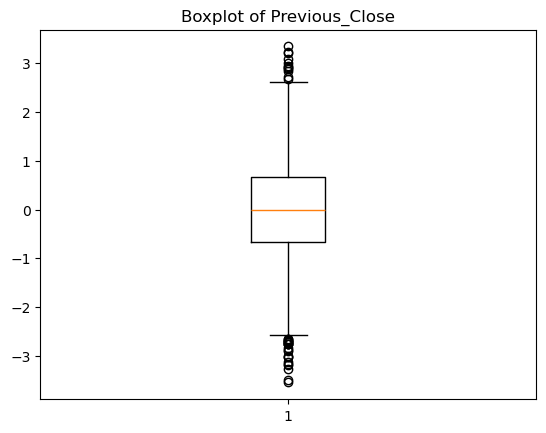

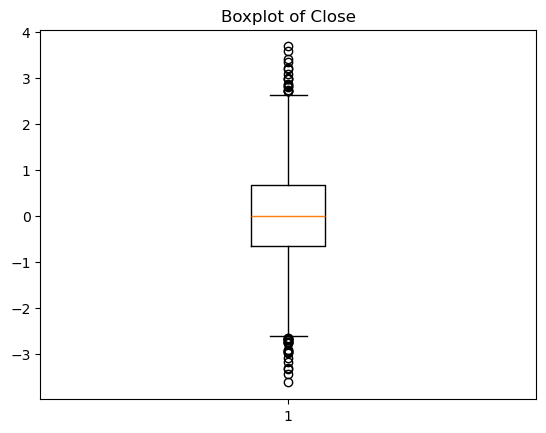

In [50]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [61]:
X = df.drop('Close', axis=1)
y = df['Close']

In [63]:
from sklearn.metrics import r2_score
import numpy as np

pt = PowerTransformer(method='yeo-johnson')
X_train_transformed = pt.fit_transform(X_train)
X_test_transformed = pt.transform(X_test)

rf_model.fit(X_train_transformed, y_train)
lr_model.fit(X_train_transformed, y_train)

rf_pred = rf_model.predict(X_test_transformed)
lr_pred = lr_model.predict(X_test_transformed)

def evaluate_r2(y_true, y_pred, X_test_data, model_name):
    r2 = r2_score(y_true, y_pred)
    
    n = len(y_true)
    p = X_test_data.shape[1]
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    
    print(f"--- {model_name} Metrics ---")
    print(f"R² Score:          {r2:.4f}")
    print(f"Adjusted R² Score: {adj_r2:.4f}\n")

evaluate_r2(y_test, rf_pred, X_test_transformed, "Random Forest Regressor")
evaluate_r2(y_test, lr_pred, X_test_transformed, "Linear Regression")

--- Random Forest Regressor Metrics ---
R² Score:          0.7188
Adjusted R² Score: 0.7174

--- Linear Regression Metrics ---
R² Score:          0.7572
Adjusted R² Score: 0.7560

